## Natasha test

Датасет: `ScoutieAutoML/russian-news-telegram-dataset`

In [1]:
!pip -q install --no-cache-dir \
    "pandas==2.2.2" \
    "pyarrow==18.1.0" \
    "natasha==1.6.0" \
    "datasets>=2.20.0" \
    "huggingface_hub" \
    "tqdm" \
    "matplotlib"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 154.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 47.8 MB/s eta 0:00:00


In [2]:
import inspect
from collections import namedtuple

if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")

    def getargspec(func):
        spec = inspect.getfullargspec(func)
        return ArgSpec(
            args=spec.args,
            varargs=spec.varargs,
            keywords=spec.varkw,
            defaults=spec.defaults,
        )

    inspect.getargspec = getargspec


import sys
import os
import itertools
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset

from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsNERTagger,
    NamesExtractor,
    Doc,
    PER,
)

print("Python:", sys.version)
print("pandas:", pd.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.2.2


In [3]:
DATASET_NAME = "ScoutieAutoML/russian-news-telegram-dataset"

# Сколько строк взять для оценки. Полный датасет ~97k - тяжеловато для бейзлайна.
SAMPLE_SIZE = 2000
RANDOM_SEED = 42

ds = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
)

# buffer_size большой, чтобы шафл был достаточно случайным.
ds_shuffled = ds.shuffle(seed=RANDOM_SEED, buffer_size=10000)

rows = []
for item in tqdm(
    itertools.islice(ds_shuffled, SAMPLE_SIZE),
    total=SAMPLE_SIZE,
    desc="Sampling",
):
    text = item.get("text") or ""
    raw_ners = item.get("ners") or []
    # raw_ners это list[dict]; делаем shallow copy чтобы оторваться от стрима
    ners = [dict(e) for e in raw_ners if isinstance(e, dict)]
    rows.append({"text": text, "ners": ners})

df = pd.DataFrame(rows)

# Выкидываем пустые тексты, если такие попались.
df = df[df["text"].str.len() > 0].reset_index(drop=True)

print("shape:", df.shape)
print("columns:", df.columns.tolist())

display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Sampling:   0%|          | 0/2000 [00:00<?, ?it/s]

shape: (2000, 2)
columns: ['text', 'ners']


,text,ners
0,В Москве 19-летний парень отдал мошенникам зол...,"[{'ner': 'Москве', 'lemma': 'москва', 'label':..."
1,МЧС России показало кадры тушения пожара в Чеч...,"[{'ner': 'МЧС', 'lemma': 'мчс', 'label': 'ORG'..."
2,"😂\nДва друга повесили свое фото в Маке, и этог...","[{'ner': 'Маке', 'lemma': 'маке', 'label': 'LO..."
3,Очень странное поведение учителя истории из Ст...,"[{'ner': 'Ставрополья', 'lemma': 'ставрополье'..."
4,"Курьер, которой Лариса Долина отдавала деньги,...","[{'ner': 'Лариса Долина', 'lemma': 'лариса дол..."


In [4]:
gold_label_counter = Counter()

for ners in df["ners"]:
    for ent in ners:
        if not isinstance(ent, dict):
            continue
        gold_label_counter[ent.get("label", "UNKNOWN")] += 1

label_stats = (
    pd.DataFrame(gold_label_counter.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(label_stats)

,label,count
0,LOC,4184
1,ORG,3648
2,NUM,2782
3,PER,2438
4,DATE,347
5,CARDINAL,26
6,PRODUCT,5
7,NORP,5
8,WORK_OF_ART,3
9,FAC,2


In [6]:
TARGET_GOLD_LABEL = "PER"  # ФИО

segmenter = Segmenter()

emb = NewsEmbedding()
ner_tagger = NewsNERTagger(emb)

morph_vocab = MorphVocab()
names_extractor = NamesExtractor(morph_vocab)

In [7]:
def tokenize_with_natasha(text):
    """
    Токенизирует текст сегментером Natasha.

    Returns:
        tokens:  list[str]              - тексты токенов
        offsets: list[(start, stop)]    - char-границы токенов в исходном тексте
        doc:     Doc                    - уже сегментированный, готов к tag_ner
    """
    doc = Doc(text)
    doc.segment(segmenter)

    tokens = []
    offsets = []

    for tok in doc.tokens:
        tokens.append(tok.text)
        offsets.append((tok.start, tok.stop))

    for tok_text, (start, stop) in zip(tokens, offsets):
        assert text[start:stop] == tok_text, (tok_text, text[start:stop], start, stop)

    return tokens, offsets, doc


def char_spans_to_token_bio(offsets, spans, label):
    """
    Преобразует char-спаны в BIO-теги по токенам.

    offsets: list[(start, stop)] - char-границы каждого токена
    spans:   list[(start, stop)] - char-границы сущностей
    label:   тип сущности для BIO (например, "PER")
    """
    bio_tags = ["O"] * len(offsets)

    spans_sorted = sorted(spans, key=lambda s: (s[0], s[1]))

    for span_start, span_stop in spans_sorted:
        if span_start >= span_stop:
            continue

        touched = []

        for token_id, (tok_start, tok_stop) in enumerate(offsets):
            intersects = max(tok_start, span_start) < min(tok_stop, span_stop)

            if intersects:
                touched.append(token_id)

        if not touched:
            continue

        first_token_id = touched[0]

        if bio_tags[first_token_id] == "O":
            bio_tags[first_token_id] = "B-" + label

        for token_id in touched[1:]:
            if bio_tags[token_id] == "O":
                bio_tags[token_id] = "I-" + label

    return bio_tags


def tag_type(tag):
    """
    'B-PER' -> 'PER'
    'I-PER' -> 'PER'
    'O'     -> 'O'
    """
    tag = str(tag)

    if tag == "O":
        return "O"

    if "-" in tag:
        return tag.split("-", 1)[1]

    return tag


def is_gold_per(tag):
    return tag_type(tag) == TARGET_GOLD_LABEL


def is_pred_per(tag):
    return tag_type(tag) == "PER"

In [9]:
def gold_per_spans(ners_list):
    """Достаёт char-спаны gold разметки только для метки PER."""
    spans = []

    for ent in ners_list:
        if not isinstance(ent, dict):
            continue
        if ent.get("label") != TARGET_GOLD_LABEL:
            continue

        start = ent.get("start_pos")
        stop = ent.get("end_pos")

        if start is None or stop is None:
            continue

        spans.append((int(start), int(stop)))

    return spans


def predict_natasha_per(text):
    """
    На вход: сырой текст.
    На выход:
        tokens:   list[str]
        offsets:  list[(start, stop)]
        pred_bio: list[str]   - BIO-теги PER по нашей токенизации
        persons:  list[dict]  - спаны PER от Natasha + лемматизированное ФИО
    """
    tokens, offsets, doc = tokenize_with_natasha(text)
    doc.tag_ner(ner_tagger)

    person_spans = []
    persons = []

    for span in doc.spans:
        if span.type != PER and str(span.type) != "PER":
            continue

        person_spans.append((span.start, span.stop))

        fact_dict = {}

        try:
            span.extract_fact(names_extractor)
            if span.fact is not None:
                fact_dict = span.fact.as_dict
        except Exception:
            fact_dict = {}

        persons.append({
            "text": span.text,
            "start_char": span.start,
            "stop_char": span.stop,
            "first": fact_dict.get("first"),
            "last": fact_dict.get("last"),
            "middle": fact_dict.get("middle"),
        })

    pred_bio = char_spans_to_token_bio(offsets, person_spans, "PER")

    assert len(pred_bio) == len(tokens)

    return tokens, offsets, pred_bio, persons

In [10]:
example_id = None

for i, ners in enumerate(df["ners"]):
    if any(isinstance(e, dict) and e.get("label") == TARGET_GOLD_LABEL for e in ners):
        example_id = i
        break

print("example_id:", example_id)

row = df.iloc[example_id]
text = row["text"]
ners_list = list(row["ners"])

tokens, offsets, pred_bio, persons = predict_natasha_per(text)

gold_spans = gold_per_spans(ners_list)
gold_bio = char_spans_to_token_bio(offsets, gold_spans, "PER")

print("\nTEXT (первые 500 символов):")
print(text[:500])

print("\nTOKEN | GOLD | PRED (только не-O):")
for i, (tok, g, p) in enumerate(zip(tokens, gold_bio, pred_bio)):
    if g != "O" or p != "O":
        print(i, repr(tok), g, p)

print("\nGold PER-сущности:")
display(pd.DataFrame(
    [e for e in ners_list if isinstance(e, dict) and e.get("label") == TARGET_GOLD_LABEL]
))

print("\nNatasha persons:")
display(pd.DataFrame(persons))

example_id: 0

TEXT (первые 500 символов):
В Москве 19-летний парень отдал мошенникам золотые монеты и перевел им более 11 млн рублей «в целях декларирования имущества». Он думал, что участвует в операции ФСБ.
19 октября Артему позвонили «сотрудники ФСБ», а потом и «Центробанка». Они убедили его поучаствовать в секретной спецоперации по поимке мошенников. По указаниям звонивших, Артем взял из сейфа родителей 66 тысяч долларов, а также ордена, медали и украшения и передал их неизвестным, чтобы положить на «безопасный счет».
Этим дело не о

TOKEN | GOLD | PRED (только не-O):
33 'Артему' B-PER B-PER
62 'Артем' B-PER B-PER
135 'Финально' O B-PER
136 'Артем' B-PER I-PER
153 'Артем' B-PER B-PER

Gold PER-сущности:


,ner,lemma,label,start_pos,end_pos
0,Артему,артём,PER,178,184
1,Артем,артём,PER,339,344
2,Артем,артём,PER,764,769
3,Артем,артём,PER,845,850



Natasha persons:


,text,start_char,stop_char,first,last,middle
0,Артему,178,184,None,None,None
1,Артем,339,344,None,None,None
2,Финально Артем,755,769,None,None,None
3,Артем,845,850,None,None,None


In [11]:
all_tokens = []
all_gold_bio = []
all_pred_bio = []
all_persons = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Natasha NER"):
    text = row.text
    ners_list = list(row.ners) if row.ners is not None else []

    tokens, offsets, pred_bio, persons = predict_natasha_per(text)
    gold_spans = gold_per_spans(ners_list)
    gold_bio = char_spans_to_token_bio(offsets, gold_spans, "PER")

    assert len(tokens) == len(gold_bio) == len(pred_bio)

    all_tokens.append(tokens)
    all_gold_bio.append(gold_bio)
    all_pred_bio.append(pred_bio)
    all_persons.append(persons)

df["tokens"] = all_tokens
df["gold_bio"] = all_gold_bio
df["natasha_bio"] = all_pred_bio
df["natasha_persons"] = all_persons

display(df[["text", "tokens", "gold_bio", "natasha_bio", "natasha_persons"]].head())

Natasha NER:   0%|          | 0/2000 [00:00<?, ?it/s]

,text,tokens,gold_bio,natasha_bio,natasha_persons
0,В Москве 19-летний парень отдал мошенникам зол...,"[В, Москве, 19-летний, парень, отдал, мошенник...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[{'text': 'Артему', 'start_char': 178, 'stop_c..."
1,МЧС России показало кадры тушения пожара в Чеч...,"[МЧС, России, показало, кадры, тушения, пожара...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",[]
2,"😂\nДва друга повесили свое фото в Маке, и этог...","[😂, Два, друга, повесили, свое, фото, в, Маке,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, B-PER, O, O, O, O, O, O,...","[{'text': 'Маке', 'start_char': 33, 'stop_char..."
3,Очень странное поведение учителя истории из Ст...,"[Очень, странное, поведение, учителя, истории,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[{'text': 'Валерий Александрович', 'start_char..."
4,"Курьер, которой Лариса Долина отдавала деньги,...","[Курьер, ,, которой, Лариса, Долина, отдавала,...","[O, O, O, B-PER, I-PER, O, O, O, O, O, O, O, O...","[O, O, O, B-PER, I-PER, O, O, O, O, O, O, O, O...","[{'text': 'Лариса Долина', 'start_char': 16, '..."


In [12]:
def compute_token_metrics(df):
    """
    Бинарные токен-уровневые метрики (PER vs не-PER):

        natasha | gold
    tp: per     | per
    fp: per     | not per
    fn: not per | per
    tn: not per | not per
    """
    tp = fp = fn = tn = 0

    for gold_tags, pred_tags in zip(df["gold_bio"], df["natasha_bio"]):
        gold_tags = list(gold_tags)
        pred_tags = list(pred_tags)

        assert len(gold_tags) == len(pred_tags)

        for gold_tag, pred_tag in zip(gold_tags, pred_tags):
            gold_is_per = is_gold_per(gold_tag)
            pred_is_per = is_pred_per(pred_tag)

            if gold_is_per and pred_is_per:
                tp += 1
            elif not gold_is_per and pred_is_per:
                fp += 1
            elif gold_is_per and not pred_is_per:
                fn += 1
            else:
                tn += 1

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def extract_spans_from_bio(bio_tags):
    """
    Из BIO-последовательности собирает спаны (start_token, end_token, label),
    end - exclusive.
    """
    spans = []
    i = 0
    n = len(bio_tags)

    while i < n:
        tag = bio_tags[i]

        if not tag.startswith("B-"):
            i += 1
            continue

        label = tag[2:]
        start = i
        i += 1

        while i < n and bio_tags[i] == "I-" + label:
            i += 1

        spans.append((start, i, label))

    return spans


def compute_entity_metrics(df, label="PER"):
    """Span-level (exact match) метрики для одной BIO-метки."""
    tp = fp = fn = 0

    for gold_tags, pred_tags in zip(df["gold_bio"], df["natasha_bio"]):
        gold_spans = {(s, e) for s, e, l in extract_spans_from_bio(gold_tags) if l == label}
        pred_spans = {(s, e) for s, e, l in extract_spans_from_bio(pred_tags) if l == label}

        tp += len(gold_spans & pred_spans)
        fp += len(pred_spans - gold_spans)
        fn += len(gold_spans - pred_spans)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


token_metrics = compute_token_metrics(df)
entity_metrics = compute_entity_metrics(df, label="PER")

metrics_df = pd.DataFrame([
    {"level": "token_binary_PER", **token_metrics},
    {"level": "entity_exact_PER", **entity_metrics},
])

display(metrics_df)

,level,tp,fp,fn,tn,precision,recall,f1
0,token_binary_PER,3260,316,464,150336.0,0.911633,0.875403,0.893151
1,entity_exact_PER,2050,301,388,NaN,0.871969,0.840853,0.856129


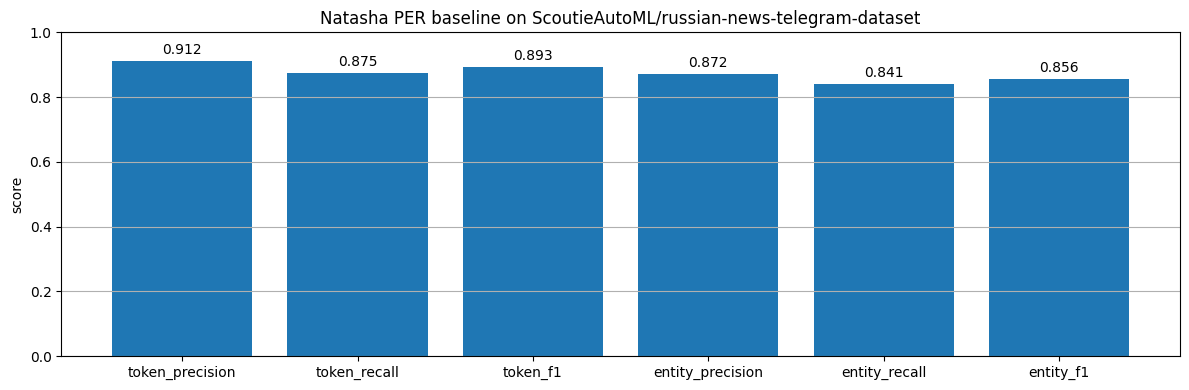

,metric,value
0,token_precision,0.911633
1,token_recall,0.875403
2,token_f1,0.893151
3,entity_precision,0.871969
4,entity_recall,0.840853
5,entity_f1,0.856129


In [14]:
plot_rows = [
    {"metric": "token_precision",  "value": token_metrics["precision"]},
    {"metric": "token_recall",     "value": token_metrics["recall"]},
    {"metric": "token_f1",         "value": token_metrics["f1"]},
    {"metric": "entity_precision", "value": entity_metrics["precision"]},
    {"metric": "entity_recall",    "value": entity_metrics["recall"]},
    {"metric": "entity_f1",        "value": entity_metrics["f1"]},
]

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(12, 4))
plt.bar(plot_df["metric"], plot_df["value"])
plt.ylim(0, 1)
plt.ylabel("score")
plt.title("Natasha PER baseline on ScoutieAutoML/russian-news-telegram-dataset")
plt.grid(axis="y")

for i, v in enumerate(plot_df["value"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

display(plot_df)

In [15]:
error_rows = []

for row_id, row in df.iterrows():
    tokens = list(row["tokens"])
    gold_tags = list(row["gold_bio"])
    pred_tags = list(row["natasha_bio"])

    for token_id, (token, gold_tag, pred_tag) in enumerate(zip(tokens, gold_tags, pred_tags)):
        gold_is_per = is_gold_per(gold_tag)
        pred_is_per = is_pred_per(pred_tag)

        if gold_is_per == pred_is_per:
            continue

        if gold_is_per and not pred_is_per:
            error_type = "FN_missed_by_natasha"
        else:
            error_type = "FP_extra_by_natasha"

        error_rows.append({
            "row_id": row_id,
            "token_id": token_id,
            "token": token,
            "gold": gold_tag,
            "pred": pred_tag,
            "error_type": error_type,
            "text": row["text"][:300],
        })

errors_df = pd.DataFrame(error_rows)

print("Errors:", len(errors_df))

if len(errors_df):
    print("\nПо типам ошибок:")
    display(errors_df["error_type"].value_counts())
    display(errors_df.head(200))
else:
    display(errors_df)

Errors: 780

По типам ошибок:


,count
error_type,
FN_missed_by_natasha,464
FP_extra_by_natasha,316


,row_id,token_id,token,gold,pred,error_type,text
0,0,135,Финально,O,B-PER,FP_extra_by_natasha,В Москве 19-летний парень отдал мошенникам зол...
1,2,7,Маке,O,B-PER,FP_extra_by_natasha,"😂\nДва друга повесили свое фото в Маке, и этог..."
2,5,98,Долиной,O,B-PER,FP_extra_by_natasha,До 28 января продлён срок следствия по делу об...
3,8,92,Сырский,B-PER,O,FN_missed_by_natasha,Спецоперация. Обстановка и главные события на ...
4,8,122,Зеленский,B-PER,O,FN_missed_by_natasha,Спецоперация. Обстановка и главные события на ...
...,...,...,...,...,...,...,...
195,410,13,Фиала,O,B-PER,FP_extra_by_natasha,Европа перестанет быть приоритетом для США пос...
196,414,0,Дагестанка,O,B-PER,FP_extra_by_natasha,Дагестанка оставила семью\nи всё мирское\nи уш...
197,415,55,Калигула,B-PER,O,FN_missed_by_natasha,В истории балашихинского отравителя появилось ...
198,418,10,Манхэттена,B-PER,O,FN_missed_by_natasha,Подробностей о P.Diddy больше не будет\nФедера...
